# 03 - Metaheuristic Optimization

This notebook performs hyperparameter optimization for deep learning models used in global solar radiation forecasting.

Metaheuristics included:
- Particle Swarm Optimization (PSO)
- Artificial Bee Colony (ABC)
- Genetic Algorithm (GA)

Optimized parameters:
- number of neurons
- dropout rate
- learning rate
- batch size

The optimized models are compared against baseline models.

In [3]:
import os
import json
import time
import random
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

In [4]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print(tf.config.list_physical_devices('GPU'))
print(tf.config.list_logical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[LogicalDevice(name='/device:GPU:0', device_type='GPU')]


In [5]:
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [6]:
BASE_DIR = "/home/jovyan/work"

OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
ARRAYS_DIR = os.path.join(OUTPUT_DIR, "arrays")
SCALERS_DIR = os.path.join(OUTPUT_DIR, "scalers")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
MODELS_DIR = os.path.join(OUTPUT_DIR, "optimized_models")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

In [7]:
with open(os.path.join(OUTPUT_DIR, "preprocessing_config.json"), "r") as f:
    CONFIG = json.load(f)

CONFIG

{'file_name': 'EMA--OMUAQ_Table1.txt',
 'timestamp_column': 'TIMESTAMP',
 'target': 'SolRad_Avg',
 'window_size': 12,
 'horizon': 6,
 'train_ratio': 0.7,
 'val_ratio': 0.15,
 'test_ratio': 0.15,
 'irradiance_threshold': 50,
 'features': ['TempAir_Avg',
  'HumRel',
  'PreBar_Avg',
  'VelVto_S_WVT',
  'DirVto_D1_WVT',
  'DirVto_SD1_WVT',
  'hour',
  'dayofyear',
  'month'],
 'n_features': 9,
 'n_samples': 28034,
 'train_size': 19623,
 'val_size': 4205,
 'test_size': 4206}

In [8]:
X_train = np.load(os.path.join(ARRAYS_DIR, "X_train.npy"))
y_train = np.load(os.path.join(ARRAYS_DIR, "y_train.npy"))

X_val = np.load(os.path.join(ARRAYS_DIR, "X_val.npy"))
y_val = np.load(os.path.join(ARRAYS_DIR, "y_val.npy"))

X_test = np.load(os.path.join(ARRAYS_DIR, "X_test.npy"))
y_test = np.load(os.path.join(ARRAYS_DIR, "y_test.npy"))

daylight_test = np.load(os.path.join(ARRAYS_DIR, "daylight_test.npy"))

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (19623, 12, 9) (19623, 1)
Val: (4205, 12, 9) (4205, 1)
Test: (4206, 12, 9) (4206, 1)


In [9]:
scaler_y = joblib.load(os.path.join(SCALERS_DIR, "scaler_y.pkl"))

In [10]:
WINDOW_SIZE = X_train.shape[1]
N_FEATURES = X_train.shape[2]

OPTIMIZATION_EPOCHS = 25
FINAL_EPOCHS = 100

PATIENCE_OPT = 4
PATIENCE_FINAL = 10

SEED = 42
set_seed(SEED)

print("Window size:", WINDOW_SIZE)
print("Features:", N_FEATURES)

Window size: 12
Features: 9


In [11]:
def inverse_transform(data):
    return scaler_y.inverse_transform(data)


def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


def calculate_daylight_metrics(y_true, y_pred, daylight_mask):
    y_true_day = y_true[daylight_mask]
    y_pred_day = y_pred[daylight_mask]

    return calculate_metrics(y_true_day, y_pred_day)

In [12]:
BOUNDS = {
    "units_1": (32, 128),
    "units_2": (16, 64),
    "dropout_rate": (0.10, 0.40),
    "learning_rate": (0.0001, 0.005),
    "batch_size": (16, 64)
}

PARAMETER_NAMES = list(BOUNDS.keys())

LOWER_BOUNDS = np.array([BOUNDS[p][0] for p in PARAMETER_NAMES])
UPPER_BOUNDS = np.array([BOUNDS[p][1] for p in PARAMETER_NAMES])

print(PARAMETER_NAMES)
print(LOWER_BOUNDS)
print(UPPER_BOUNDS)

['units_1', 'units_2', 'dropout_rate', 'learning_rate', 'batch_size']
[3.2e+01 1.6e+01 1.0e-01 1.0e-04 1.6e+01]
[1.28e+02 6.40e+01 4.00e-01 5.00e-03 6.40e+01]


In [13]:
def decode_solution(solution):
    solution = np.clip(solution, LOWER_BOUNDS, UPPER_BOUNDS)

    params = {
        "units_1": int(round(solution[0])),
        "units_2": int(round(solution[1])),
        "dropout_rate": float(solution[2]),
        "learning_rate": float(solution[3]),
        "batch_size": int(round(solution[4]))
    }

    valid_batch_sizes = np.array([16, 32, 64])
    params["batch_size"] = int(
        valid_batch_sizes[np.argmin(np.abs(valid_batch_sizes - params["batch_size"]))]
    )

    return params

In [14]:
def build_lstm_model(params):
    model = Sequential([
        LSTM(
            params["units_1"],
            return_sequences=True,
            input_shape=(WINDOW_SIZE, N_FEATURES)
        ),
        Dropout(params["dropout_rate"]),

        LSTM(params["units_2"]),
        Dropout(params["dropout_rate"]),

        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=params["learning_rate"]),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [15]:
fitness_history = []


def objective_function(solution):
    params = decode_solution(solution)

    try:
        tf.keras.backend.clear_session()
        set_seed(SEED)

        model = build_lstm_model(params)

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE_OPT,
            restore_best_weights=True
        )

        model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=OPTIMIZATION_EPOCHS,
            batch_size=params["batch_size"],
            callbacks=[early_stopping],
            verbose=0
        )

        y_pred_val = model.predict(X_val, verbose=0)

        y_val_inv = inverse_transform(y_val)
        y_pred_val_inv = inverse_transform(y_pred_val)

        mae = mean_absolute_error(y_val_inv, y_pred_val_inv)

        fitness_history.append({
            **params,
            "fitness": mae,
            "status": "ok"
        })

        return mae

    except Exception as e:
        tf.keras.backend.clear_session()

        fitness_history.append({
            **params,
            "fitness": 999999,
            "status": "failed",
            "error": str(e)[:300]
        })

        print("Failed configuration:", params)
        print("Assigned penalty fitness.")

        return 999999

In [16]:
def run_pso(
    objective_function,
    lower_bounds,
    upper_bounds,
    n_particles=20,
    iterations=30,
    w=0.7,
    c1=1.5,
    c2=1.5,
    seed=42
):
    np.random.seed(seed)

    dim = len(lower_bounds)

    positions = np.random.uniform(
        lower_bounds,
        upper_bounds,
        size=(n_particles, dim)
    )

    velocities = np.zeros((n_particles, dim))

    personal_best_positions = positions.copy()
    personal_best_scores = np.array([
        objective_function(pos) for pos in positions
    ])

    best_index = np.argmin(personal_best_scores)
    global_best_position = personal_best_positions[best_index].copy()
    global_best_score = personal_best_scores[best_index]

    convergence = [global_best_score]

    for iteration in range(iterations):
        print(f"PSO iteration {iteration + 1}/{iterations}")

        r1 = np.random.rand(n_particles, dim)
        r2 = np.random.rand(n_particles, dim)

        velocities = (
            w * velocities
            + c1 * r1 * (personal_best_positions - positions)
            + c2 * r2 * (global_best_position - positions)
        )

        positions = positions + velocities
        positions = np.clip(positions, lower_bounds, upper_bounds)

        for i in range(n_particles):
            score = objective_function(positions[i])

            if score < personal_best_scores[i]:
                personal_best_scores[i] = score
                personal_best_positions[i] = positions[i].copy()

                if score < global_best_score:
                    global_best_score = score
                    global_best_position = positions[i].copy()

        convergence.append(global_best_score)
        print("Best MAE:", global_best_score)

    return global_best_position, global_best_score, convergence

In [17]:
start_time = time.time()

pso_best_solution, pso_best_score, pso_convergence = run_pso(
    objective_function=objective_function,
    lower_bounds=LOWER_BOUNDS,
    upper_bounds=UPPER_BOUNDS,
    seed=SEED
)

pso_time = time.time() - start_time

pso_params = decode_solution(pso_best_solution)

print("PSO best score:", pso_best_score)
print("PSO params:", pso_params)
print("PSO time:", pso_time)

I0000 00:00:1779067072.026113     208 cuda_dnn.cc:461] Loaded cuDNN version 91900


PSO iteration 1/30
Best MAE: 55.47567184709856
PSO iteration 2/30
Best MAE: 55.21184844466066
PSO iteration 3/30
Best MAE: 55.120789867204046
PSO iteration 4/30
Best MAE: 54.84888469156056
PSO iteration 5/30
Best MAE: 54.66565419360333
PSO iteration 6/30
Best MAE: 54.66565419360333
PSO iteration 7/30
Best MAE: 54.66565419360333
PSO iteration 8/30
Best MAE: 54.66565419360333
PSO iteration 9/30
Best MAE: 54.66565419360333
PSO iteration 10/30
Best MAE: 54.66565419360333
PSO iteration 11/30
Best MAE: 54.66565419360333
PSO iteration 12/30
Best MAE: 54.66565419360333
PSO iteration 13/30
Best MAE: 54.66565419360333
PSO iteration 14/30
Best MAE: 54.66565419360333
PSO iteration 15/30
Best MAE: 54.66565419360333
PSO iteration 16/30
Best MAE: 54.61589140354835
PSO iteration 17/30
Best MAE: 54.50720628234532
PSO iteration 18/30
Best MAE: 54.50720628234532
PSO iteration 19/30
Best MAE: 54.50720628234532
PSO iteration 20/30
Best MAE: 54.50720628234532
PSO iteration 21/30
Best MAE: 54.50720628234532


In [18]:
def run_abc(
    objective_function,
    lower_bounds,
    upper_bounds,
    colony_size=8,
    iterations=8,
    limit=4,
    seed=42
):
    np.random.seed(seed)

    dim = len(lower_bounds)

    food_sources = np.random.uniform(
        lower_bounds,
        upper_bounds,
        size=(colony_size, dim)
    )

    fitness = np.array([
        objective_function(source) for source in food_sources
    ])

    trial = np.zeros(colony_size)

    best_index = np.argmin(fitness)
    best_solution = food_sources[best_index].copy()
    best_score = fitness[best_index]

    convergence = [best_score]

    for iteration in range(iterations):
        print(f"ABC iteration {iteration + 1}/{iterations}")

        # Employed bees
        for i in range(colony_size):
            k = np.random.choice([idx for idx in range(colony_size) if idx != i])
            phi = np.random.uniform(-1, 1, dim)

            candidate = food_sources[i] + phi * (food_sources[i] - food_sources[k])
            candidate = np.clip(candidate, lower_bounds, upper_bounds)

            candidate_score = objective_function(candidate)

            if candidate_score < fitness[i]:
                food_sources[i] = candidate
                fitness[i] = candidate_score
                trial[i] = 0
            else:
                trial[i] += 1

        probabilities = (1 / (1 + fitness))
        probabilities = probabilities / probabilities.sum()

        # Onlooker bees
        for _ in range(colony_size):
            i = np.random.choice(range(colony_size), p=probabilities)
            k = np.random.choice([idx for idx in range(colony_size) if idx != i])
            phi = np.random.uniform(-1, 1, dim)

            candidate = food_sources[i] + phi * (food_sources[i] - food_sources[k])
            candidate = np.clip(candidate, lower_bounds, upper_bounds)

            candidate_score = objective_function(candidate)

            if candidate_score < fitness[i]:
                food_sources[i] = candidate
                fitness[i] = candidate_score
                trial[i] = 0
            else:
                trial[i] += 1

        # Scout bees
        for i in range(colony_size):
            if trial[i] >= limit:
                food_sources[i] = np.random.uniform(lower_bounds, upper_bounds)
                fitness[i] = objective_function(food_sources[i])
                trial[i] = 0

        current_best_index = np.argmin(fitness)

        if fitness[current_best_index] < best_score:
            best_score = fitness[current_best_index]
            best_solution = food_sources[current_best_index].copy()

        convergence.append(best_score)
        print("Best MAE:", best_score)

    return best_solution, best_score, convergence

In [19]:
'''
start_time = time.time()

abc_best_solution, abc_best_score, abc_convergence = run_abc(
    objective_function=objective_function,
    lower_bounds=LOWER_BOUNDS,
    upper_bounds=UPPER_BOUNDS,
    colony_size=8,
    iterations=8,
    limit=4,
    seed=SEED
)

abc_time = time.time() - start_time

abc_params = decode_solution(abc_best_solution)

print("ABC best score:", abc_best_score)
print("ABC params:", abc_params)
print("ABC time:", abc_time)
'''

'\nstart_time = time.time()\n\nabc_best_solution, abc_best_score, abc_convergence = run_abc(\n    objective_function=objective_function,\n    lower_bounds=LOWER_BOUNDS,\n    upper_bounds=UPPER_BOUNDS,\n    colony_size=8,\n    iterations=8,\n    limit=4,\n    seed=SEED\n)\n\nabc_time = time.time() - start_time\n\nabc_params = decode_solution(abc_best_solution)\n\nprint("ABC best score:", abc_best_score)\nprint("ABC params:", abc_params)\nprint("ABC time:", abc_time)\n'

In [20]:
def tournament_selection(population, fitness, tournament_size=3):
    indices = np.random.choice(len(population), tournament_size, replace=False)
    best_index = indices[np.argmin(fitness[indices])]

    return population[best_index].copy()


def crossover(parent1, parent2):
    alpha = np.random.rand(len(parent1))

    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = alpha * parent2 + (1 - alpha) * parent1

    return child1, child2


def mutate(individual, lower_bounds, upper_bounds, mutation_rate=0.2):
    mutated = individual.copy()

    for i in range(len(individual)):
        if np.random.rand() < mutation_rate:
            mutation_range = upper_bounds[i] - lower_bounds[i]
            mutated[i] += np.random.normal(0, 0.1 * mutation_range)

    return np.clip(mutated, lower_bounds, upper_bounds)


def run_ga(
    objective_function,
    lower_bounds,
    upper_bounds,
    population_size=20,
    generations=30,
    mutation_rate=0.2,
    elite_size=2,
    seed=42
):
    np.random.seed(seed)

    dim = len(lower_bounds)

    population = np.random.uniform(
        lower_bounds,
        upper_bounds,
        size=(population_size, dim)
    )

    fitness = np.array([
        objective_function(individual) for individual in population
    ])

    best_index = np.argmin(fitness)
    best_solution = population[best_index].copy()
    best_score = fitness[best_index]

    convergence = [best_score]

    for generation in range(generations):
        print(f"GA generation {generation + 1}/{generations}")

        new_population = []

        elite_indices = np.argsort(fitness)[:elite_size]

        for idx in elite_indices:
            new_population.append(population[idx].copy())

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitness)
            parent2 = tournament_selection(population, fitness)

            child1, child2 = crossover(parent1, parent2)

            child1 = mutate(child1, lower_bounds, upper_bounds, mutation_rate)
            child2 = mutate(child2, lower_bounds, upper_bounds, mutation_rate)

            new_population.append(child1)

            if len(new_population) < population_size:
                new_population.append(child2)

        population = np.array(new_population)

        fitness = np.array([
            objective_function(individual) for individual in population
        ])

        current_best_index = np.argmin(fitness)

        if fitness[current_best_index] < best_score:
            best_score = fitness[current_best_index]
            best_solution = population[current_best_index].copy()

        convergence.append(best_score)
        print("Best MAE:", best_score)

    return best_solution, best_score, convergence

In [21]:
start_time = time.time()

ga_best_solution, ga_best_score, ga_convergence = run_ga(
    objective_function=objective_function,
    lower_bounds=LOWER_BOUNDS,
    upper_bounds=UPPER_BOUNDS,
    mutation_rate=0.2,
    elite_size=2,
    seed=SEED
)

ga_time = time.time() - start_time

ga_params = decode_solution(ga_best_solution)

print("GA best score:", ga_best_score)
print("GA params:", ga_params)
print("GA time:", ga_time)

GA generation 1/30
Best MAE: 56.78091703325591
GA generation 2/30
Best MAE: 56.78091703325591
GA generation 3/30
Best MAE: 56.78091703325591
GA generation 4/30
Best MAE: 56.297011168005525
GA generation 5/30
Best MAE: 56.160939824492
GA generation 6/30
Best MAE: 55.54430704559294
GA generation 7/30
Best MAE: 55.179836962549246
GA generation 8/30
Best MAE: 53.33675000175449
GA generation 9/30
Best MAE: 53.33675000175449
GA generation 10/30
Best MAE: 53.33675000175449
GA generation 11/30
Best MAE: 53.33675000175449
GA generation 12/30
Best MAE: 53.33675000175449
GA generation 13/30
Best MAE: 53.33675000175449
GA generation 14/30
Best MAE: 53.33675000175449
GA generation 15/30
Best MAE: 53.33675000175449
GA generation 16/30
Best MAE: 53.276598355292
GA generation 17/30
Best MAE: 53.276598355292
GA generation 18/30
Best MAE: 53.276598355292
GA generation 19/30
Best MAE: 53.276598355292
GA generation 20/30
Best MAE: 53.276598355292
GA generation 21/30
Best MAE: 53.276598355292
GA generation

In [23]:
'''optimization_results = [
    {
        "Optimizer": "PSO",
        **pso_params,
        "Validation_MAE": pso_best_score,
        "Optimization_Time_Seconds": pso_time
    },
    {
        "Optimizer": "ABC",
        **abc_params,
        "Validation_MAE": abc_best_score,
        "Optimization_Time_Seconds": abc_time
    },
    {
        "Optimizer": "GA",
        **ga_params,
        "Validation_MAE": ga_best_score,
        "Optimization_Time_Seconds": ga_time
    }
]
'''
optimization_results = [
    {
        "Optimizer": "PSO",
        **pso_params,
        "Validation_MAE": pso_best_score,
        "Optimization_Time_Seconds": pso_time
    },
    {
        "Optimizer": "GA",
        **ga_params,
        "Validation_MAE": ga_best_score,
        "Optimization_Time_Seconds": ga_time
    }
]

optimization_results_df = pd.DataFrame(optimization_results)

optimization_results_df

,Optimizer,units_1,units_2,dropout_rate,learning_rate,batch_size,Validation_MAE,Optimization_Time_Seconds
0,PSO,81,58,0.190421,0.003177,64,53.553499,18676.626832
1,GA,78,30,0.100000,0.003319,64,53.276598,25904.235287


In [25]:
optimization_results_path = os.path.join(
    RESULTS_DIR,
    "optimization_results.csv"
)

optimization_results_df.to_csv(
    optimization_results_path,
    index=False
)

print("Saved:", optimization_results_path)

Saved: /home/jovyan/work/outputs/results/optimization_results.csv


In [26]:
fitness_history_df = pd.DataFrame(fitness_history)

fitness_history_path = os.path.join(
    RESULTS_DIR,
    "optimization_fitness_history.csv"
)

fitness_history_df.to_csv(
    fitness_history_path,
    index=False
)

print("Saved:", fitness_history_path)

Saved: /home/jovyan/work/outputs/results/optimization_fitness_history.csv


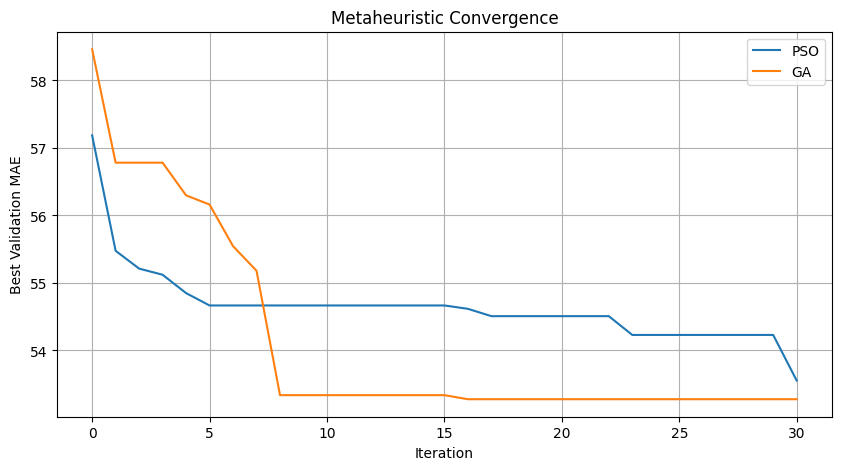

Saved: /home/jovyan/work/outputs/figures/optimization_convergence.png


In [28]:
plt.figure(figsize=(10, 5))

plt.plot(pso_convergence, label="PSO")
#plt.plot(abc_convergence, label="ABC")
plt.plot(ga_convergence, label="GA")

plt.title("Metaheuristic Convergence")
plt.xlabel("Iteration")
plt.ylabel("Best Validation MAE")
plt.legend()
plt.grid(True)

convergence_path = os.path.join(
    FIGURES_DIR,
    "optimization_convergence.png"
)

plt.savefig(convergence_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", convergence_path)

In [29]:
def train_final_optimized_model(optimizer_name, params):
    tf.keras.backend.clear_session()
    set_seed(SEED)

    print(f"\nTraining final model optimized by {optimizer_name}")
    print(params)

    model = build_lstm_model(params)

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE_FINAL,
        restore_best_weights=True
    )

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=FINAL_EPOCHS,
        batch_size=params["batch_size"],
        callbacks=[early_stopping],
        verbose=1
    )

    training_time = time.time() - start_time

    y_pred_test = model.predict(X_test)

    y_test_inv = inverse_transform(y_test)
    y_pred_test_inv = inverse_transform(y_pred_test)

    overall_metrics = calculate_metrics(
        y_test_inv,
        y_pred_test_inv
    )

    daylight_metrics = calculate_daylight_metrics(
        y_test_inv,
        y_pred_test_inv,
        daylight_test
    )

    result = {
        "Optimizer": optimizer_name,

        "Test_MAE": overall_metrics["MAE"],
        "Test_RMSE": overall_metrics["RMSE"],
        "Test_R2": overall_metrics["R2"],

        "Daylight_MAE": daylight_metrics["MAE"],
        "Daylight_RMSE": daylight_metrics["RMSE"],
        "Daylight_R2": daylight_metrics["R2"],

        "Training_Time_Seconds": training_time,
        "Epochs": len(history.history["loss"]),

        **params
    }

    model_path = os.path.join(
        MODELS_DIR,
        f"LSTM_{optimizer_name}_optimized.keras"
    )

    model.save(model_path)

    return result, history, model, y_test_inv, y_pred_test_inv

In [30]:
final_results = []
final_histories = {}
final_predictions = {}

for _, row in optimization_results_df.iterrows():
    optimizer_name = row["Optimizer"]

    params = {
        "units_1": int(row["units_1"]),
        "units_2": int(row["units_2"]),
        "dropout_rate": float(row["dropout_rate"]),
        "learning_rate": float(row["learning_rate"]),
        "batch_size": int(row["batch_size"])
    }

    result, history, model, y_true, y_pred = train_final_optimized_model(
        optimizer_name,
        params
    )

    final_results.append(result)
    final_histories[optimizer_name] = history
    final_predictions[optimizer_name] = {
        "y_true": y_true,
        "y_pred": y_pred
    }


Training final model optimized by PSO
{'units_1': 81, 'units_2': 58, 'dropout_rate': 0.19042147853060823, 'learning_rate': 0.0031768829810334045, 'batch_size': 64}
Epoch 1/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0155 - mae: 0.0780 - val_loss: 0.0189 - val_mae: 0.0782
Epoch 2/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0052 - mae: 0.0423 - val_loss: 0.0134 - val_mae: 0.0631
Epoch 3/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0046 - mae: 0.0388 - val_loss: 0.0106 - val_mae: 0.0513
Epoch 4/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0043 - mae: 0.0374 - val_loss: 0.0102 - val_mae: 0.0516
Epoch 5/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0037 - mae: 0.0341 - val_loss: 0.0107 - val_mae: 0.0518
Epoch 6/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0038 - mae: 0.0344 - val_loss: 0.0102 - val_mae: 0.0521
Epoch 7/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0035 - mae: 0.0328 - val_loss: 0.0096 - val_mae: 0.0462
E

In [31]:
final_results_df = pd.DataFrame(final_results)

final_results_df

,Optimizer,Test_MAE,Test_RMSE,Test_R2,Daylight_MAE,Daylight_RMSE,Daylight_R2,Training_Time_Seconds,Epochs,units_1,units_2,dropout_rate,learning_rate,batch_size
0,PSO,57.337343,111.660989,0.916335,107.462846,154.938887,0.781792,49.626996,20,81,58,0.190421,0.003177,64
1,GA,58.759426,113.954042,0.912863,112.801450,158.315735,0.772177,52.146689,19,78,30,0.100000,0.003319,64


In [32]:
final_results_path = os.path.join(
    RESULTS_DIR,
    "final_optimized_results.csv"
)

final_results_df.to_csv(
    final_results_path,
    index=False
)

print("Saved:", final_results_path)

Saved: /home/jovyan/work/outputs/results/final_optimized_results.csv


In [33]:
def plot_predictions(y_true, y_pred, title, n_points=300):
    plt.figure(figsize=(15, 5))

    plt.plot(y_true[:n_points], label="Real")
    plt.plot(y_pred[:n_points], label="Predicted")

    plt.title(title)
    plt.xlabel("Time step")
    plt.ylabel("Solar Radiation")
    plt.legend()
    plt.grid(True)

    plt.show()

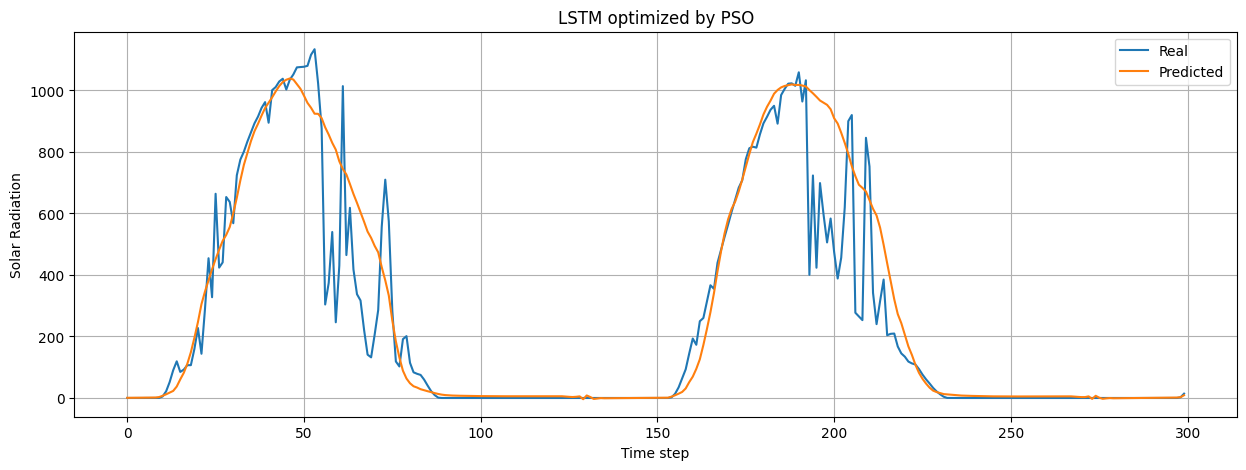

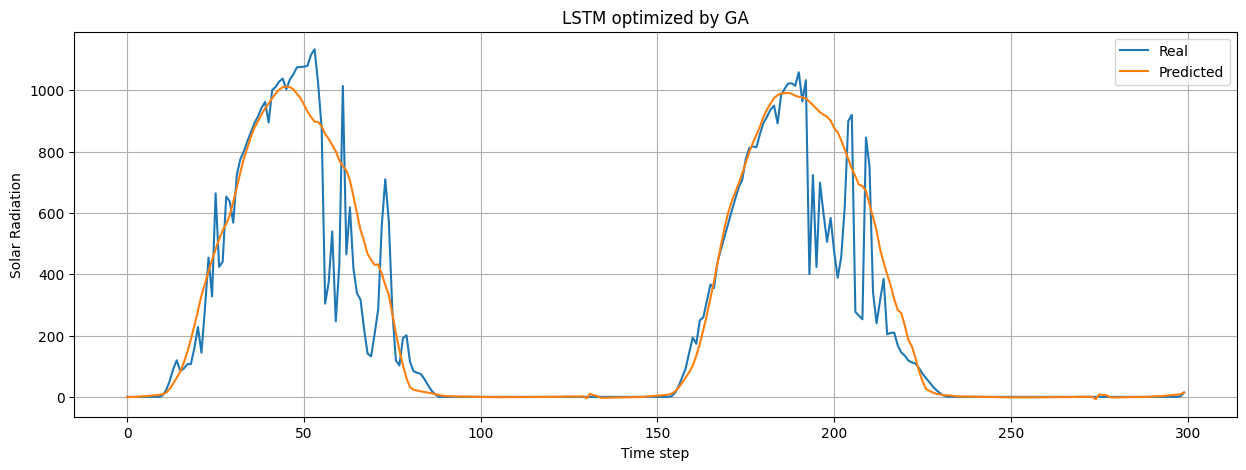

In [34]:
for optimizer_name, data in final_predictions.items():
    plot_predictions(
        data["y_true"],
        data["y_pred"],
        f"LSTM optimized by {optimizer_name}"
    )

In [35]:
best_optimizer = final_results_df.sort_values(
    "Daylight_MAE"
).iloc[0]

best_optimizer

Optimizer                       PSO
Test_MAE                  57.337343
Test_RMSE                111.660989
Test_R2                    0.916335
Daylight_MAE             107.462846
Daylight_RMSE            154.938887
Daylight_R2                0.781792
Training_Time_Seconds     49.626996
Epochs                           20
units_1                          81
units_2                          58
dropout_rate               0.190421
learning_rate              0.003177
batch_size                       64
Name: 0, dtype: object

In [36]:
best_optimizer_path = os.path.join(
    RESULTS_DIR,
    "best_optimizer.json"
)

with open(best_optimizer_path, "w") as f:
    json.dump(
        best_optimizer.to_dict(),
        f,
        indent=4,
        default=str
    )

print("Saved:", best_optimizer_path)

Saved: /home/jovyan/work/outputs/results/best_optimizer.json
